# Template Matching Results — v4

Builds on `template_matching_results_executed.ipynb` (v1/v2/v3) by adding:
- **v4 sweeps** (Procrustes, joint means, pairwise pooled PCA, keypoint exclusion, cosine distance) — same row schema as v3.
- **Harm analysis** outputs from `experiments/harm_analysis.py` — characterizes whether SLEAP/DANNCE disagreements are *systematic* (survivable for training) or *random*.

For every approach we report **recall, precision, and F1 at 300 ms** rather than recall alone.

**Note on session filtering:** unlike the prior executed notebook, this one reports metrics across *all* sessions, not just `temporal_offset_ms > 100`. The reason: v3 and v4 use a per-session offset estimator that returns 0 for sessions where the SLEAP-DANNCE divergence is largest — exactly the sessions we care about. Filtering by offset would drop most of the data we want to characterize.

In [23]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

BASE = Path('/home/yutaka-sprague/CLIRB_analyses/results/metrics')
FIGS = Path('/home/yutaka-sprague/CLIRB_analyses/results/figures/harm_analysis')

CONFIGS = [
    ('R1', 'secondary'),
    ('R1', 'primary'),
    ('R2', 'primary'),
    ('R3', 'primary'),
]

def load_results(version):
    """Load all four (rat, config) result CSVs for a given version (v3 or v4)."""
    out = {}
    for rat, cfg in CONFIGS:
        p = BASE / f'{rat}_{cfg}_{version}_results.csv'
        if p.exists():
            out[(rat, cfg)] = pd.read_csv(p)
    return out

v3 = load_results('v3')
v4 = load_results('v4')
harm = {}
for rat, cfg in CONFIGS:
    p = BASE / f'{rat}_{cfg}_harm_summary.csv'
    if p.exists():
        harm[(rat, cfg)] = pd.read_csv(p)

print(f'v3 datasets: {len(v3)}; v4 datasets: {len(v4)}; harm datasets: {len(harm)}')
for k in v4:
    print(f'  v4 {k}: {len(v4[k]):,} rows, {v4[k]["session"].nunique()} sessions, '
          f'groups={sorted(v4[k]["group"].unique())}')

v3 datasets: 4; v4 datasets: 4; harm datasets: 4
  v4 ('R1', 'secondary'): 13,168 rows, 72 sessions, groups=['M_procrustes', 'N_joint_means', 'N_joint_means_metric', 'O_pairwise_pooled', 'P_kp_exclude', 'Q_cosine']
  v4 ('R1', 'primary'): 11,172 rows, 72 sessions, groups=['M_procrustes', 'N_joint_means', 'N_joint_means_metric', 'O_pairwise_pooled', 'P_kp_exclude', 'Q_cosine']
  v4 ('R2', 'primary'): 12,476 rows, 74 sessions, groups=['M_procrustes', 'N_joint_means', 'N_joint_means_metric', 'O_pairwise_pooled', 'P_kp_exclude', 'Q_cosine']
  v4 ('R3', 'primary'): 12,960 rows, 76 sessions, groups=['M_procrustes', 'N_joint_means', 'N_joint_means_metric', 'O_pairwise_pooled', 'P_kp_exclude', 'Q_cosine']


## 1. Best operating point per approach (F1 + precision + recall)

For each (rat, config) and each experiment group, find the parameter setting that maximizes mean SLEAP F1 at 300 ms tolerance over good-offset sessions. Report recall and precision at that operating point.

In [24]:
def best_per_group(df, metric='sl_f1_300', offset_cut=None):
    """Per (group, exp_name): mean across sessions; return top setting per group.

    If offset_cut is set, restrict to sessions with temporal_offset_ms > offset_cut.
    """
    sub = df if offset_cut is None else df[df['temporal_offset_ms'] > offset_cut]
    if sub.empty:
        return pd.DataFrame()
    grp = (sub.groupby(['group', 'exp_name'])
             [['sl_recall_300', 'sl_precision_300', 'sl_f1_300',
               'dn_recall_300', 'dn_precision_300', 'dn_f1_300']]
             .mean()
             .reset_index())
    idx = grp.groupby('group')[metric].idxmax()
    return grp.loc[idx].sort_values(metric, ascending=False).reset_index(drop=True)

for (rat, cfg), df in v4.items():
    print(f'\n{rat} {cfg} — best per group:')
    print(best_per_group(df).round(3).to_string(index=False))


R1 secondary — best per group:
               group               exp_name  sl_recall_300  sl_precision_300  sl_f1_300  dn_recall_300  dn_precision_300  dn_f1_300
   O_pairwise_pooled      O_pw_n2_s1.50_mo3          0.695             0.835      0.749           1.00             1.000      1.000
        M_procrustes  M_proc_cal2_s1.50_mo3          0.711             0.730      0.714           1.00             1.000      1.000
            Q_cosine              Q_cos_p25          0.706             0.601      0.640           0.91             0.669      0.763
       N_joint_means N_jm_uniform_s1.50_mo3          0.576             0.514      0.504           1.00             1.000      1.000
        P_kp_exclude         P_K0_s1.50_mo3          0.379             0.580      0.423           1.00             1.000      1.000
N_joint_means_metric           N_jm_cos_p25          0.772             0.336      0.416           0.89             0.466      0.578

R1 primary — best per group:
              

## 2. Recall vs precision frontier across all approaches

Joining v3 and v4 in one place, plot every group/exp_name pair on a recall-precision plane to see the achievable Pareto frontier per (rat, config).

/tmp/ipykernel_1778284/3296853596.py:28: RuntimeWarning: divide by zero encountered in divide
  p_grid = (f1 * r_grid) / (2 * r_grid - f1)
/tmp/ipykernel_1778284/3296853596.py:28: RuntimeWarning: divide by zero encountered in divide
  p_grid = (f1 * r_grid) / (2 * r_grid - f1)
/tmp/ipykernel_1778284/3296853596.py:28: RuntimeWarning: divide by zero encountered in divide
  p_grid = (f1 * r_grid) / (2 * r_grid - f1)
/tmp/ipykernel_1778284/3296853596.py:28: RuntimeWarning: divide by zero encountered in divide
  p_grid = (f1 * r_grid) / (2 * r_grid - f1)


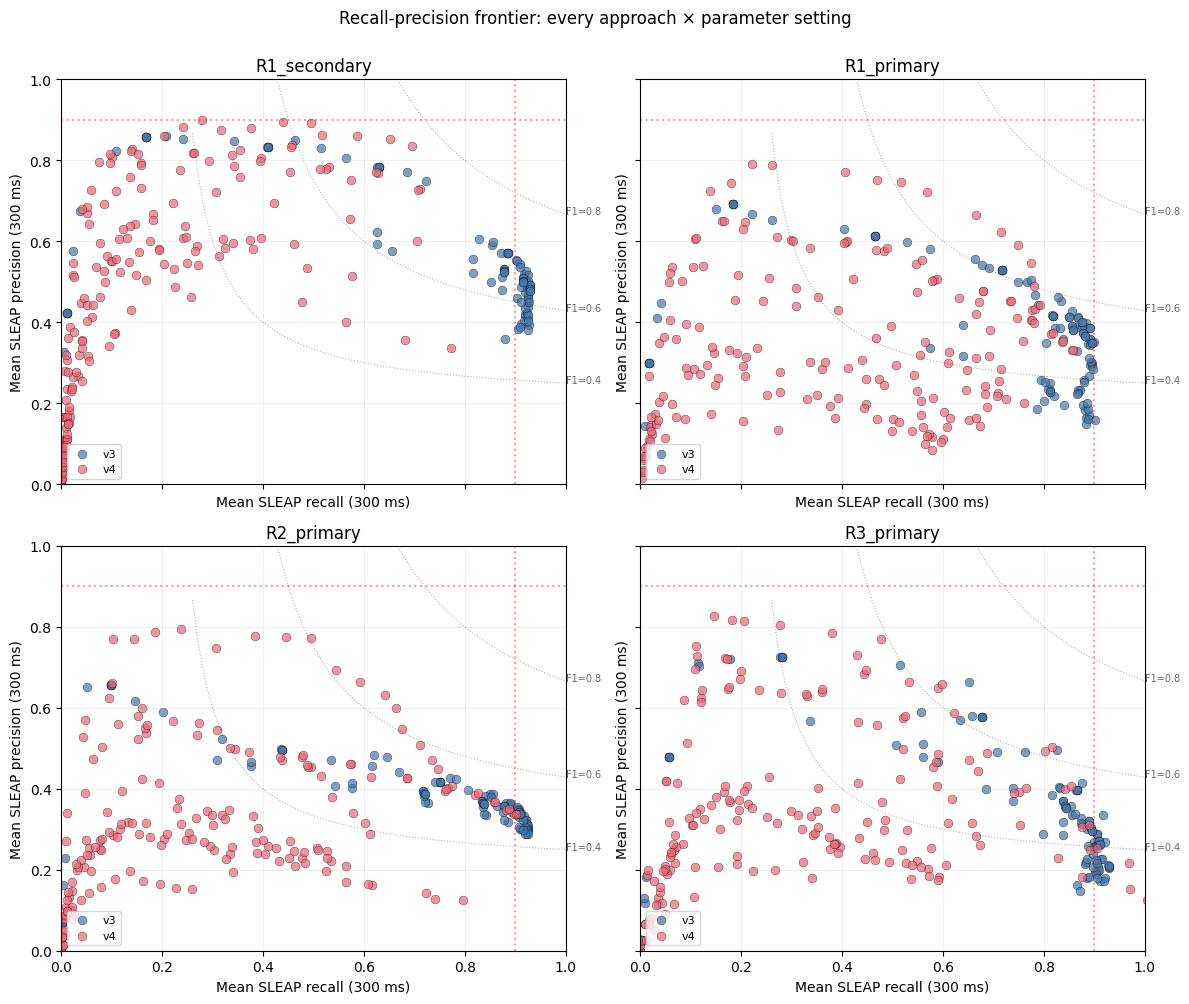

In [25]:
def all_versions(rat, cfg):
    parts = []
    for ver, store in [('v3', v3), ('v4', v4)]:
        if (rat, cfg) in store:
            d = store[(rat, cfg)].copy()
            d['version'] = ver
            parts.append(d)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
for ax, (rat, cfg) in zip(axes.ravel(), CONFIGS):
    df = all_versions(rat, cfg)
    if df.empty:
        ax.set_title(f'{rat}_{cfg} — no data'); continue
    good = df[df['temporal_offset_ms'] >= -1e9]
    grp = (good.groupby(['version', 'group', 'exp_name'])
             [['sl_recall_300', 'sl_precision_300', 'sl_f1_300']]
             .mean()
             .reset_index())
    palette = {'v3': '#4477AA', 'v4': '#EE6677'}
    for ver, sub in grp.groupby('version'):
        ax.scatter(sub['sl_recall_300'], sub['sl_precision_300'],
                   s=40, alpha=0.7, label=ver, color=palette.get(ver, 'k'),
                   edgecolor='k', lw=0.3)
    # F1 contours
    r_grid = np.linspace(0.01, 1, 100)
    for f1 in (0.4, 0.6, 0.8):
        p_grid = (f1 * r_grid) / (2 * r_grid - f1)
        valid = (p_grid >= 0) & (p_grid <= 1)
        ax.plot(r_grid[valid], p_grid[valid], 'k:', alpha=0.3, lw=0.8)
        if valid.any():
            xi = r_grid[valid][-1]; yi = p_grid[valid][-1]
            ax.annotate(f'F1={f1}', (xi, yi), fontsize=7, alpha=0.6)
    ax.axhline(0.9, color='red', ls=':', alpha=0.4)
    ax.axvline(0.9, color='red', ls=':', alpha=0.4)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f'{rat}_{cfg}')
    ax.set_xlabel('Mean SLEAP recall (300 ms)')
    ax.set_ylabel('Mean SLEAP precision (300 ms)')
    ax.legend(loc='lower left', fontsize=8)
    ax.grid(alpha=0.2)
fig.suptitle('Recall-precision frontier: every approach × parameter setting', y=1.0)
fig.tight_layout()
plt.show()

## 3. Per-group F1 ranking (v4 only)

Which fix-categories actually matter? For each (rat, config), aggregate to the group level and show mean F1 with a precision/recall annotation.

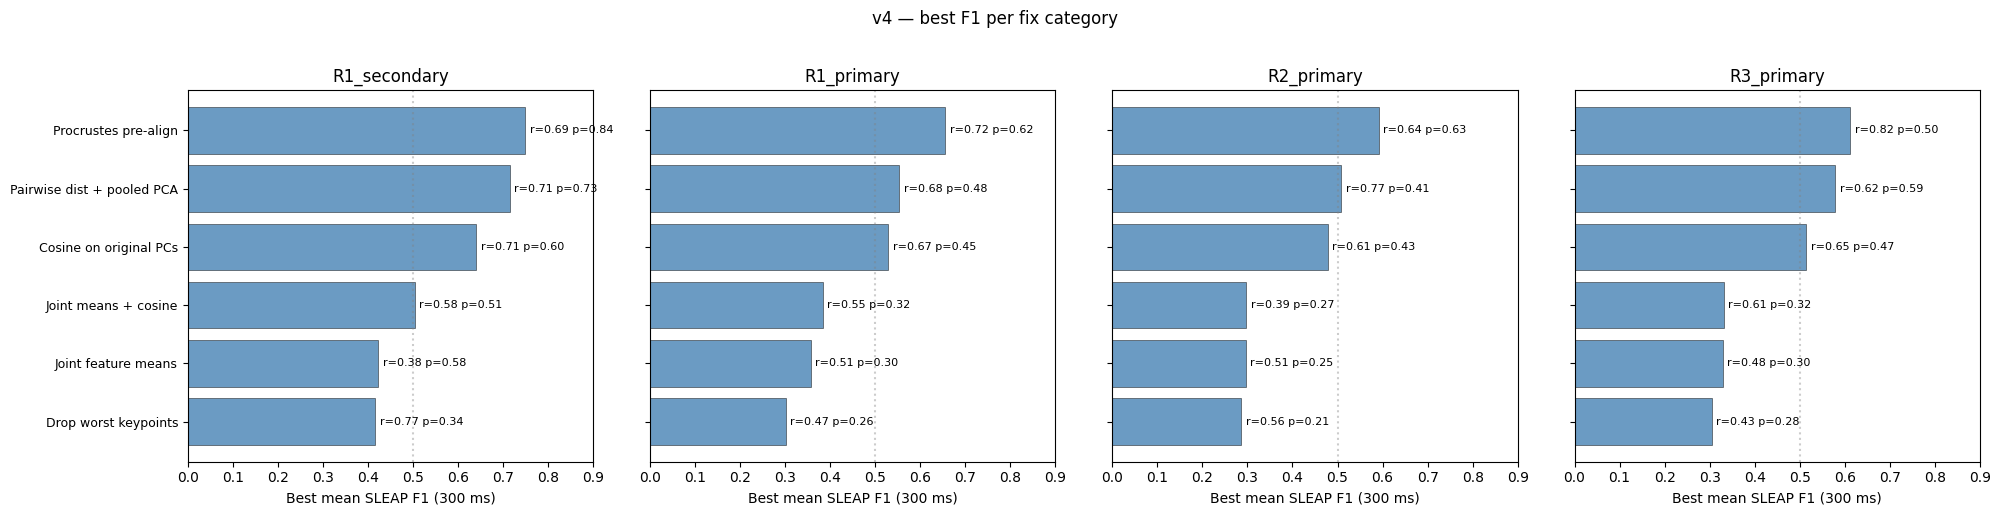

In [26]:
fig, axes = plt.subplots(1, len(v4), figsize=(5 * len(v4), 5), sharey=True)
if len(v4) == 1:
    axes = [axes]
GROUP_LABELS = {
    'M_procrustes': 'Procrustes pre-align',
    'N_joint_means': 'Joint feature means',
    'N_joint_means_metric': 'Joint means + cosine',
    'O_pairwise_pooled': 'Pairwise dist + pooled PCA',
    'P_kp_exclude': 'Drop worst keypoints',
    'Q_cosine': 'Cosine on original PCs',
}
for ax, ((rat, cfg), df) in zip(axes, v4.items()):
    good = df[df['temporal_offset_ms'] >= -1e9]
    if good.empty:
        ax.set_title(f'{rat}_{cfg} — no good sessions'); continue
    # For each group, take the best exp_name on F1
    bp = best_per_group(df)
    if bp.empty:
        ax.set_title(f'{rat}_{cfg} — no group rows'); continue
    bp['label'] = bp['group'].map(lambda g: GROUP_LABELS.get(g, g))
    bp = bp.sort_values('sl_f1_300')
    y = np.arange(len(bp))
    ax.barh(y, bp['sl_f1_300'], color='steelblue', alpha=0.8, edgecolor='k', lw=0.4)
    ax.set_yticks(y); ax.set_yticklabels(bp['label'], fontsize=9)
    for yi, (f1, r, p) in enumerate(zip(bp['sl_f1_300'], bp['sl_recall_300'], bp['sl_precision_300'])):
        ax.text(f1 + 0.01, yi, f'r={r:.2f} p={p:.2f}', va='center', fontsize=8)
    ax.axvline(0.5, color='grey', ls=':', alpha=0.4)
    ax.set_xlabel('Best mean SLEAP F1 (300 ms)')
    ax.set_title(f'{rat}_{cfg}')
    ax.set_xlim(0, max(0.9, bp['sl_f1_300'].max() + 0.15))
fig.suptitle('v4 — best F1 per fix category', y=1.02)
fig.tight_layout()
plt.show()

## 4. v3 vs v4 — does v4 beat the v3 best?

Per session, take each side's best operating point (across all groups in that version) and compare paired.

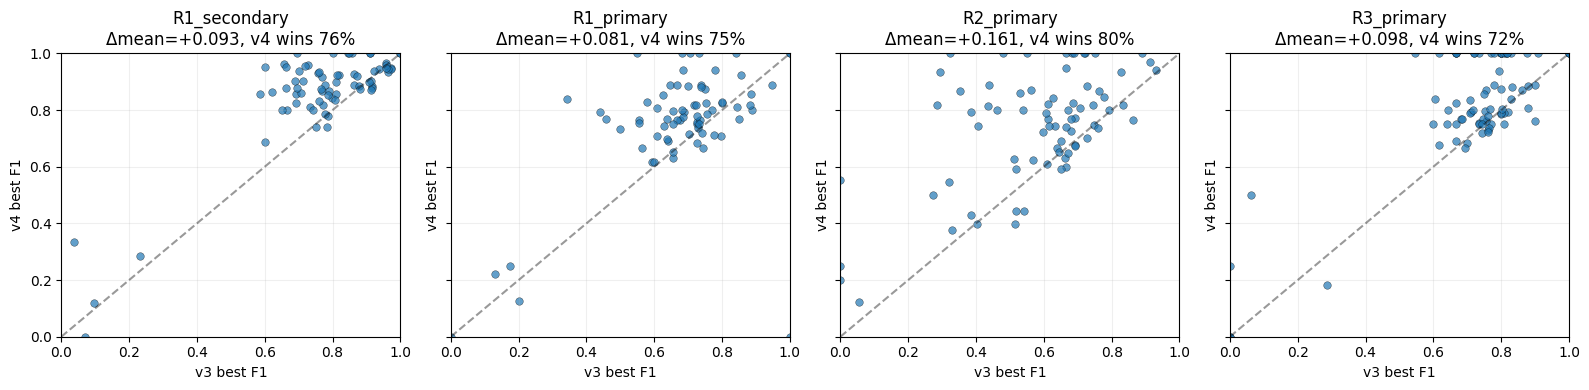

In [27]:
def best_per_session(df, metric='sl_f1_300'):
    if df.empty:
        return pd.DataFrame(columns=['session', metric, 'sl_recall_300', 'sl_precision_300'])
    idx = df.groupby('session')[metric].idxmax()
    return df.loc[idx, ['session', 'sl_recall_300', 'sl_precision_300', metric]].set_index('session')

fig, axes = plt.subplots(1, len(CONFIGS), figsize=(4 * len(CONFIGS), 4), sharey=True)
for ax, (rat, cfg) in zip(axes, CONFIGS):
    if (rat, cfg) not in v4 or (rat, cfg) not in v3:
        ax.set_title(f'{rat}_{cfg} — missing'); continue
    a = best_per_session(v3[(rat, cfg)])
    b = best_per_session(v4[(rat, cfg)])
    j = a.join(b, lsuffix='_v3', rsuffix='_v4', how='inner').dropna()
    if j.empty:
        ax.set_title(f'{rat}_{cfg} — no overlap'); continue
    ax.scatter(j['sl_f1_300_v3'], j['sl_f1_300_v4'], s=30, alpha=0.7,
               edgecolor='k', lw=0.3)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    delta = (j['sl_f1_300_v4'] - j['sl_f1_300_v3']).mean()
    win = (j['sl_f1_300_v4'] > j['sl_f1_300_v3']).mean() * 100
    ax.set_title(f'{rat}_{cfg}\nΔmean={delta:+.3f}, v4 wins {win:.0f}%')
    ax.set_xlabel('v3 best F1')
    ax.set_ylabel('v4 best F1')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## 5. Harm analysis — is the disagreement systematic?

Three diagnostics from `experiments/harm_analysis.py`:
- **Per-PC bias fraction** — `|mean error| / RMSE`. Values > 0.5 mean the cross-system error is dominantly a fixed offset, not noise. > 0.5 ⇒ systematic, < 0.3 ⇒ noise-dominated.
- **Per-keypoint bias fraction** — same metric per keypoint after egocentric normalization.
- **Distance-to-template gap** — median distance of SLEAP-only events to template *minus* median distance of consensus ("both") events to template, in DANNCE PC space. Small gap (≤ 0 or near zero) ⇒ SLEAP-only events look like consensus events from DANNCE's perspective; large positive gap ⇒ SLEAP is firing on poses that are noticeably further from the template.

In [28]:
if not harm:
    print('No harm summaries found yet. Re-run after experiments/harm_analysis.py finishes.')
else:
    rows = []
    for (rat, cfg), df in harm.items():
        d = df.dropna(subset=['recall'])
        rows.append({
            'config': f'{rat}_{cfg}',
            'n_sessions': len(d),
            'recall_mean': d['recall'].mean(),
            'precision_mean': d['precision'].mean(),
            'f1_mean': d['f1'].mean(),
            'pc_bias_frac_mean': d['pc_bias_fraction_mean'].mean(),
            'pc_bias_frac_max': d['pc_bias_fraction_max'].mean(),
            'kp_bias_frac_mean': d['kp_bias_fraction_mean'].mean(),
            'kp_bias_frac_max': d['kp_bias_fraction_max'].mean(),
            'dist_gap_sl_only_minus_both': (d['dist_to_tmpl_sl_only'] - d['dist_to_tmpl_both']).median(),
            'dist_gap_dn_only_minus_both': (d['dist_to_tmpl_dn_only'] - d['dist_to_tmpl_both']).median(),
        })
    summary = pd.DataFrame(rows).set_index('config')
    print('Harm summary (means across sessions):')
    print(summary.round(3).to_string())

Harm summary (means across sessions):
              n_sessions  recall_mean  precision_mean  f1_mean  pc_bias_frac_mean  pc_bias_frac_max  kp_bias_frac_mean  kp_bias_frac_max  dist_gap_sl_only_minus_both  dist_gap_dn_only_minus_both
config                                                                                                                                                                                            
R1_secondary          72        0.708           0.734    0.713              0.343             0.483              0.310             0.501                        6.522                        0.497
R1_primary            71        0.555           0.557    0.546              0.338             0.476              0.305             0.497                        9.459                        0.092
R2_primary            74        0.586           0.461    0.485              0.396             0.535              0.333             0.549                        9.146                 

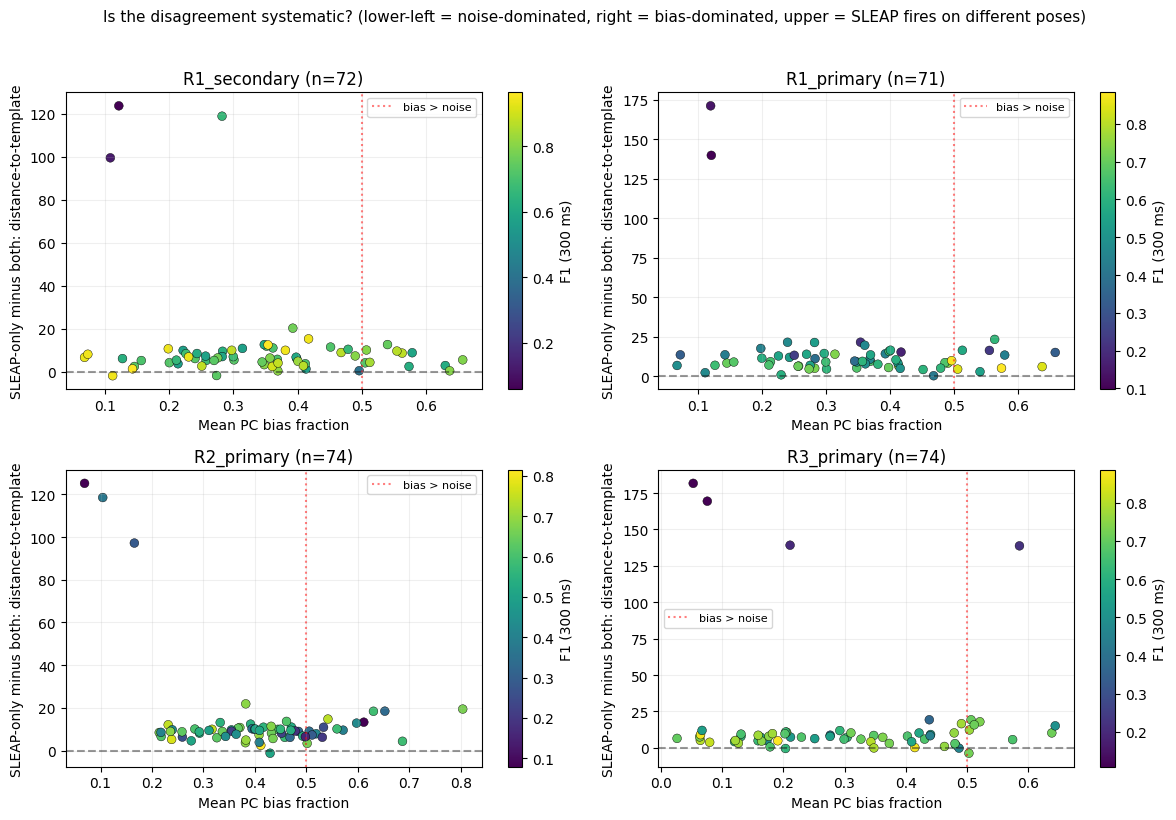

In [29]:
if harm:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, (rat, cfg) in zip(axes.ravel(), CONFIGS):
        if (rat, cfg) not in harm:
            ax.set_title(f'{rat}_{cfg} — no data'); continue
        d = harm[(rat, cfg)].dropna(subset=['pc_bias_fraction_mean'])
        if d.empty:
            ax.set_title(f'{rat}_{cfg} — empty'); continue
        gap = d['dist_to_tmpl_sl_only'] - d['dist_to_tmpl_both']
        sc = ax.scatter(d['pc_bias_fraction_mean'], gap, c=d['f1'],
                        cmap='viridis', s=40, edgecolor='k', lw=0.3)
        plt.colorbar(sc, ax=ax, label='F1 (300 ms)')
        ax.axvline(0.5, color='red', ls=':', alpha=0.5,
                   label='bias > noise')
        ax.axhline(0, color='k', ls='--', alpha=0.4)
        ax.set_xlabel('Mean PC bias fraction')
        ax.set_ylabel('SLEAP-only minus both: distance-to-template')
        ax.set_title(f'{rat}_{cfg} (n={len(d)})')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.2)
    fig.suptitle('Is the disagreement systematic? (lower-left = noise-dominated, '
                 'right = bias-dominated, upper = SLEAP fires on different poses)',
                 y=1.02, fontsize=11)
    fig.tight_layout()
    plt.show()

## 6. Per-keypoint bias — which keypoints are driving the structured error?

Aggregate the per-keypoint bias fraction across sessions and rats. A keypoint with a high bias fraction (> 0.5) across many sessions is a candidate to either drop (group P) or fine-tune more aggressively.

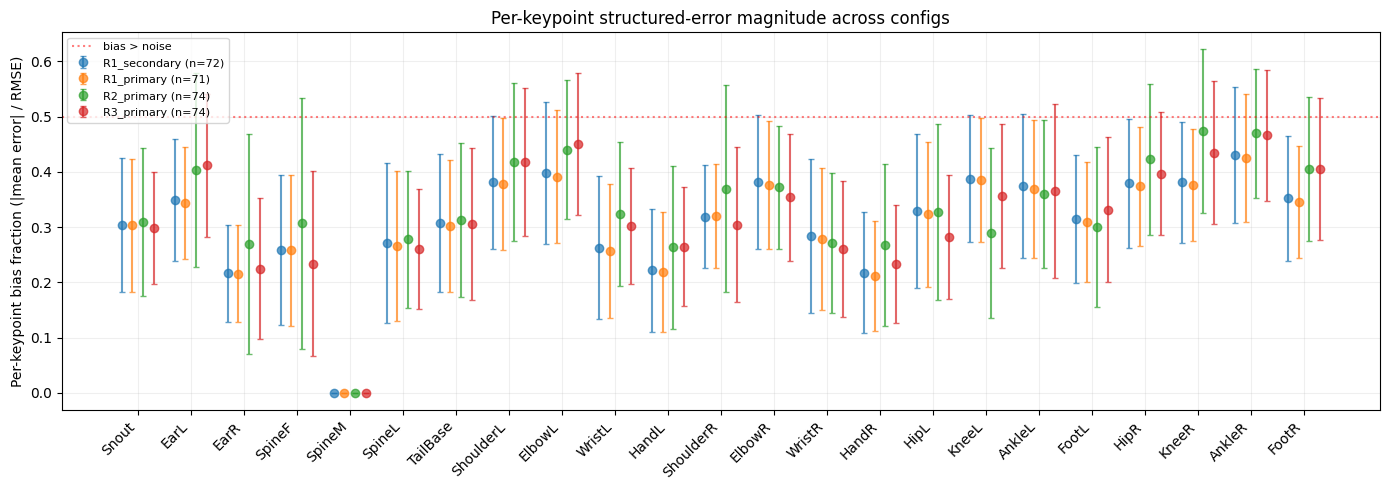

In [30]:
if harm:
    from config import NODES
    per_kp_by_config = {}
    for (rat, cfg), df in harm.items():
        rows = []
        for _, row in df.dropna(subset=['recall']).iterrows():
            d_path = FIGS / f'{rat}_{cfg}' / row['session'] / 'detail.json'
            if not d_path.exists():
                continue
            with open(d_path) as f:
                jd = json.load(f)
            if jd.get('per_kp_bias_fraction'):
                rows.append(jd['per_kp_bias_fraction'])
        if rows:
            per_kp_by_config[(rat, cfg)] = np.array(rows)  # (n_sessions, 23)

    if per_kp_by_config:
        fig, ax = plt.subplots(figsize=(14, 5))
        x = np.arange(len(NODES))
        offsets = np.linspace(-0.3, 0.3, len(per_kp_by_config))
        for off, ((rat, cfg), arr) in zip(offsets, per_kp_by_config.items()):
            mean = np.nanmean(arr, axis=0)
            std = np.nanstd(arr, axis=0)
            ax.errorbar(x + off, mean, yerr=std, fmt='o', capsize=2,
                        label=f'{rat}_{cfg} (n={len(arr)})', alpha=0.7)
        ax.axhline(0.5, color='red', ls=':', alpha=0.5,
                   label='bias > noise')
        ax.set_xticks(x); ax.set_xticklabels(NODES, rotation=45, ha='right')
        ax.set_ylabel('Per-keypoint bias fraction (|mean error| / RMSE)')
        ax.set_title('Per-keypoint structured-error magnitude across configs')
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(alpha=0.2)
        fig.tight_layout()
        plt.show()
    else:
        print('No detail.json files found yet — wait for harm_analysis to finish.')

## 7. Reward-rate impact

Does worse SLEAP/DANNCE agreement correlate with lower reward rate per minute? If yes, the disagreement is operationally costly. If no, the system is robust to it.

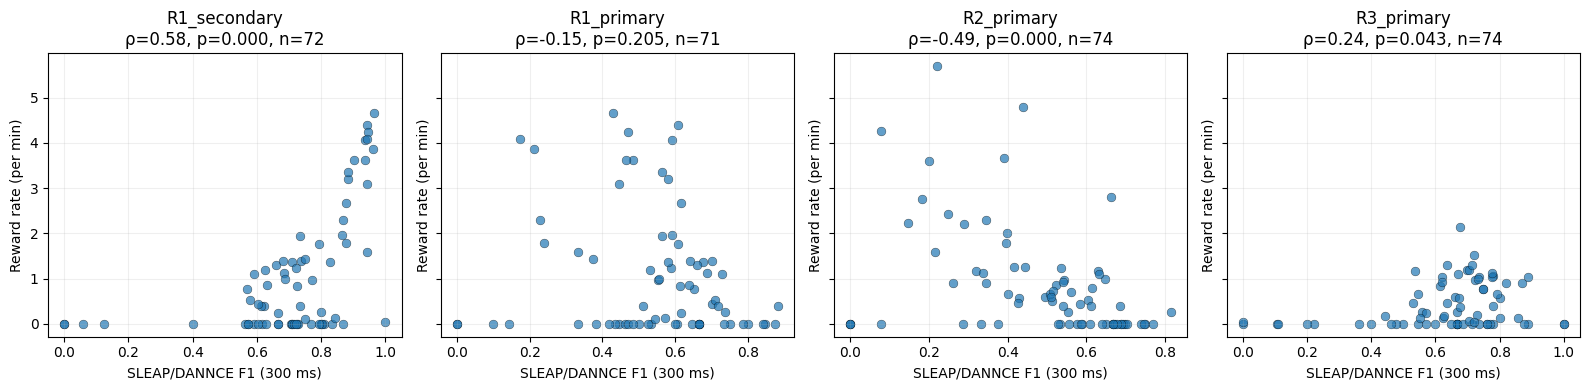

In [31]:
if harm:
    from scipy.stats import spearmanr
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
    for ax, (rat, cfg) in zip(axes, CONFIGS):
        if (rat, cfg) not in harm:
            ax.set_title(f'{rat}_{cfg} — no data'); continue
        d = harm[(rat, cfg)].dropna(subset=['f1', 'reward_reward_rate_per_min'])
        if d.empty:
            ax.set_title(f'{rat}_{cfg} — no reward data'); continue
        ax.scatter(d['f1'], d['reward_reward_rate_per_min'], s=40,
                   alpha=0.7, edgecolor='k', lw=0.3)
        rho, p = spearmanr(d['f1'], d['reward_reward_rate_per_min'])
        ax.set_title(f'{rat}_{cfg}\nρ={rho:.2f}, p={p:.3f}, n={len(d)}')
        ax.set_xlabel('SLEAP/DANNCE F1 (300 ms)')
        ax.set_ylabel('Reward rate (per min)')
        ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()

## 8. Centroid stability — is the SLEAP-only bias the same across sessions?

If SLEAP-only events sample a *consistent* offset region of DANNCE PC space across sessions, the rat is being trained on a slightly biased but stable target — which is survivable for learning. If the centroid offset drifts day-to-day, the reward target itself moves and that's a real problem.

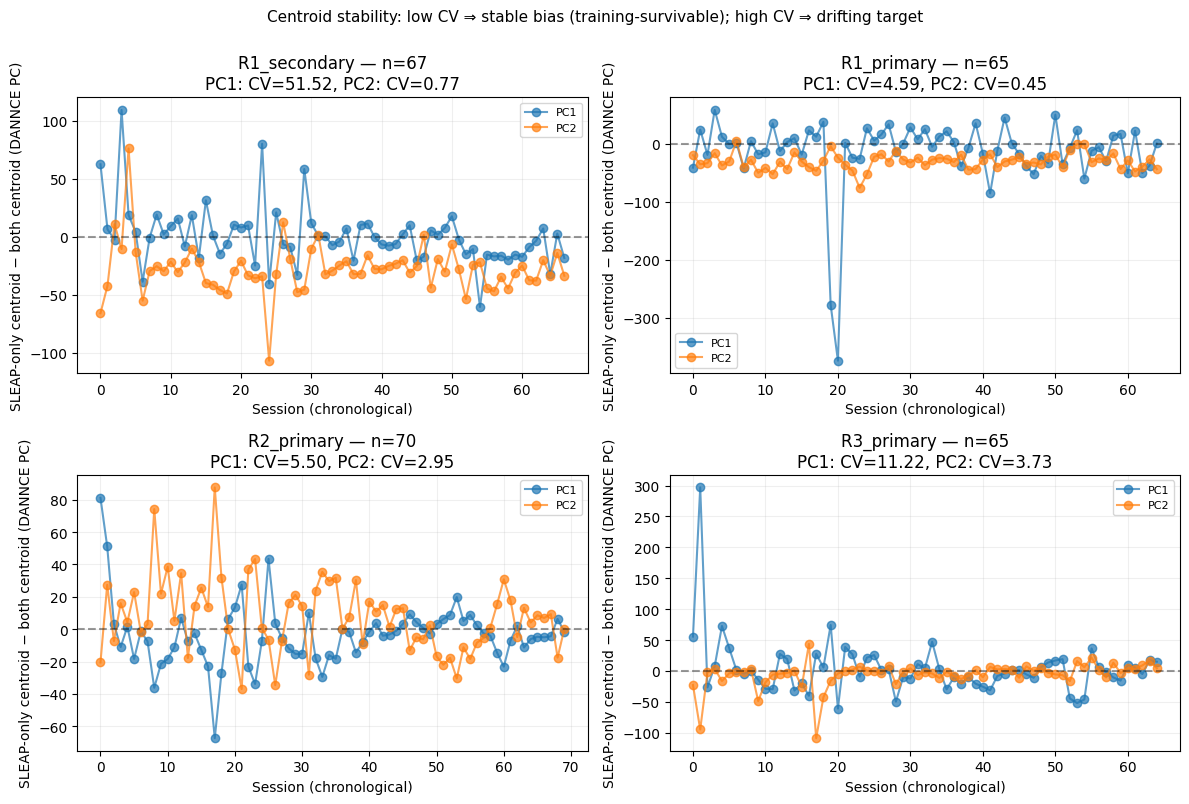

In [32]:
if harm:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, (rat, cfg) in zip(axes.ravel(), CONFIGS):
        if (rat, cfg) not in harm:
            ax.set_title(f'{rat}_{cfg} — no data'); continue
        rows = []
        sessions = []
        for _, r in harm[(rat, cfg)].dropna(subset=['recall']).iterrows():
            p = FIGS / f'{rat}_{cfg}' / r['session'] / 'detail.json'
            if not p.exists():
                continue
            with open(p) as f:
                jd = json.load(f)
            if jd.get('pose_per_pc_centroid_offset'):
                rows.append(jd['pose_per_pc_centroid_offset'])
                sessions.append(r['session'])
        if not rows:
            ax.set_title(f'{rat}_{cfg} — no centroid data'); continue
        C = np.array(rows)
        for j in range(C.shape[1]):
            ax.plot(C[:, j], 'o-', label=f'PC{j+1}', alpha=0.7)
        ax.axhline(0, color='k', ls='--', alpha=0.4)
        # Coefficient of variation as a stability score
        cv = np.nanstd(C, axis=0) / (np.abs(np.nanmean(C, axis=0)) + 1e-6)
        cv_str = ', '.join([f'PC{i+1}: CV={cv[i]:.2f}' for i in range(C.shape[1])])
        ax.set_title(f'{rat}_{cfg} — n={len(C)}\n{cv_str}')
        ax.set_xlabel('Session (chronological)')
        ax.set_ylabel('SLEAP-only centroid − both centroid (DANNCE PC)')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.2)
    fig.suptitle('Centroid stability: low CV ⇒ stable bias (training-survivable); '
                 'high CV ⇒ drifting target',
                 y=1.0, fontsize=11)
    fig.tight_layout()
    plt.show()

## 9. Summary table

Headline numbers across all four configs: best F1 from v3, best F1 from v4, harm-analysis bias diagnostics, and reward-rate correlation.

In [33]:
rows = []
for rat, cfg in CONFIGS:
    row = {'config': f'{rat}_{cfg}'}
    for ver, store in [('v3', v3), ('v4', v4)]:
        if (rat, cfg) in store:
            df = store[(rat, cfg)]
            good = df[df['temporal_offset_ms'] >= -1e9]
            if not good.empty:
                grp = good.groupby('exp_name')[
                    ['sl_f1_300','sl_recall_300','sl_precision_300']].mean()
                top = grp['sl_f1_300'].idxmax()
                row[f'{ver}_best_exp'] = top
                row[f'{ver}_best_f1'] = round(float(grp.loc[top, 'sl_f1_300']), 3)
                row[f'{ver}_best_recall'] = round(float(grp.loc[top, 'sl_recall_300']), 3)
                row[f'{ver}_best_precision'] = round(float(grp.loc[top, 'sl_precision_300']), 3)
    if (rat, cfg) in harm:
        d = harm[(rat, cfg)].dropna(subset=['recall'])
        if not d.empty:
            row['harm_pc_bias_frac_mean'] = round(d['pc_bias_fraction_mean'].mean(), 3)
            row['harm_kp_bias_frac_max'] = round(d['kp_bias_fraction_max'].mean(), 3)
            row['harm_dist_gap'] = round((d['dist_to_tmpl_sl_only'] - d['dist_to_tmpl_both']).median(), 2)
    rows.append(row)
summary = pd.DataFrame(rows).set_index('config')
print(summary.to_string())

                     v3_best_exp  v3_best_f1  v3_best_recall  v3_best_precision            v4_best_exp  v4_best_f1  v4_best_recall  v4_best_precision  harm_pc_bias_frac_mean  harm_kp_bias_frac_max  harm_dist_gap
config                                                                                                                                                                                                             
R1_secondary  J_bounds_s1.50_mo3       0.729           0.724              0.749      O_pw_n2_s1.50_mo3       0.749           0.695              0.835                   0.343                  0.501           6.52
R1_primary    J_bounds_s1.25_mo1       0.604           0.718              0.530      O_pw_n2_s1.25_mo1       0.655           0.715              0.623                   0.338                  0.497           9.46
R2_primary     I_mse_sess_p25_s1       0.526           0.645              0.479      O_pw_n2_s1.25_mo2       0.592           0.642              0.632   

## Reading the results

**A v4 group beats v3** if its best operating point lifts the recall-precision frontier on Section 2 *and* its session-paired comparison in Section 4 has a positive Δmean. Look for it consistently across configs, not just one rat.

**The disagreement is systematic** if Section 5 shows: (a) PC bias fraction > 0.5 — most error is offset, not noise, (b) a small dist-to-template gap on the y-axis, and (c) low centroid CV in Section 8. Under those conditions, training on SLEAP rewards is still consistent: SLEAP fires for poses that are slightly biased relative to DANNCE-measured poses, but the bias is the same offset every day and lives in the right neighborhood of the template.

**The disagreement is harmful** if (a) Section 7 shows a negative reward-rate correlation, (b) Section 8 shows the SLEAP-only centroid drifting across sessions, or (c) the dist-to-template gap is large and positive (SLEAP-only events are systematically further from the template).

**A keypoint stands out as a fix-it target** in Section 6 if its bias fraction is > 0.5 in multiple configs — drop it (group P), or prioritize it for the eventual model fine-tune.